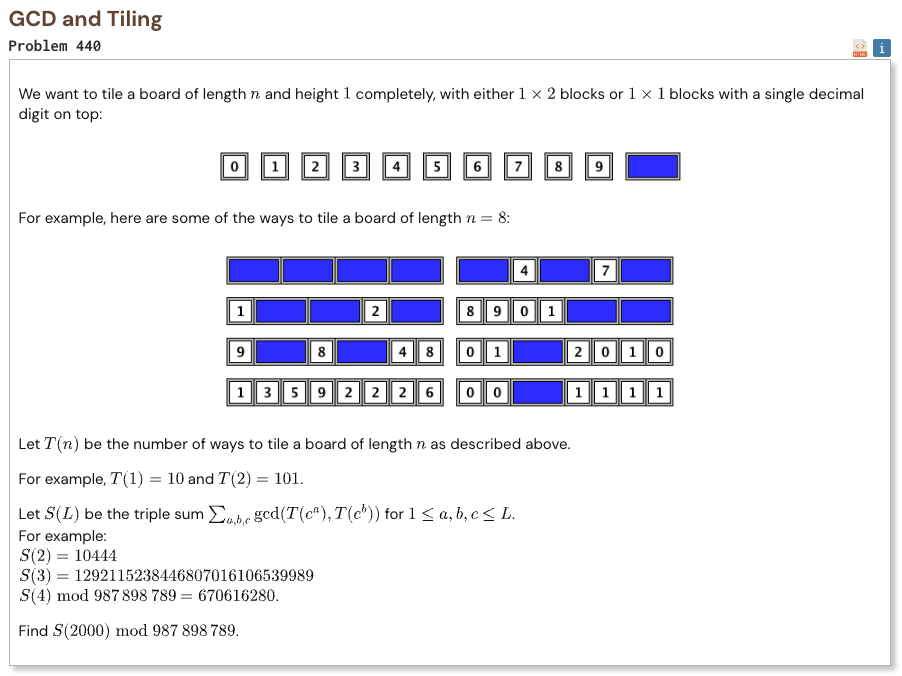

## Initial approach

-   count the tilings with a simple recurrence where a single square has 10 choices and a double block has 1 choice
-   shift this sequence into a Lucas sequence, which has a useful rule for gcd values
-   this turns the gcd of two huge tiling numbers into a much smaller problem about the exponents
-   when the powers of two inside a and b match, the gcd depends on the normal gcd of a and b
-   otherwise the gcd becomes only 10 for odd c or 1 for even c
-   use the Möbius function to count how many exponent pairs belong to each gcd value
-   calculate the needed Lucas values with fast doubling style formulas instead of building the enormous powers directly

In [1]:
%%time

L = 2000
MOD = 987_898_789
P = 10

def mobius_sieve(n):
    mu = [0] * (n + 1)
    mu[1] = 1
    primes = []
    composite = [False] * (n + 1)

    for i in range(2, n + 1):
        if not composite[i]:
            primes.append(i)
            mu[i] = -1

        for p in primes:
            value = i * p

            if value > n:
                break

            composite[value] = True

            if i % p == 0:
                mu[value] = 0
                break

            mu[value] = -mu[i]

    return mu

def build_counts(limit):
    mu = mobius_sieve(limit)
    odd_coprime = [0] * (limit + 1)

    for n in range(1, limit + 1):
        total = 0

        for d in range(1, n + 1, 2):
            if mu[d] != 0:
                count = (n // d + 1) // 2
                total += mu[d] * count * count

        odd_coprime[n] = total

    counts = [0] * (limit + 1)
    matched = 0

    for g in range(1, limit + 1):
        counts[g] = odd_coprime[limit // g]
        matched += counts[g]

    rest = limit * limit - matched

    return counts, rest

def build_lucas(limit):
    u = [0] * (limit + 2)
    u[0] = 0
    u[1] = 1

    for i in range(2, limit + 2):
        u[i] = (P * u[i - 1] + u[i - 2]) % MOD

    return u

def multiply_pair(a0, a1, b0, b1):
    previous = (b1 - P * b0) % MOD

    c0 = (a1 * b0 + a0 * previous) % MOD
    c1 = (a1 * b1 + a0 * b0) % MOD

    return c0, c1

def square_pair(a0, a1):
    c0 = a0 * (2 * a1 - P * a0) % MOD
    c1 = (a1 * a1 + a0 * a0) % MOD

    return c0, c1

def power_pair(base0, base1, exponent):
    result0 = 0
    result1 = 1

    while exponent > 0:
        if exponent % 2 == 1:
            result0, result1 = multiply_pair(
                result0,
                result1,
                base0,
                base1
            )

        exponent //= 2

        if exponent > 0:
            base0, base1 = square_pair(base0, base1)

    return result0, result1

counts, rest = build_counts(L)
u = build_lucas(L)

result = 0

for c in range(1, L + 1):
    pair0 = u[c]
    pair1 = u[c + 1]

    if c % 2 == 1:
        contribution = rest * 10
    else:
        contribution = rest

    contribution %= MOD

    for g in range(1, L + 1):
        contribution += counts[g] * pair1
        contribution %= MOD

        pair0, pair1 = power_pair(pair0, pair1, c)

    result += contribution
    result %= MOD

print("Result:", result)

Result: 970746056
CPU times: user 14.2 s, sys: 97 ms, total: 14.3 s
Wall time: 14.5 s
